In [1]:
import sys; sys.path.append('..')
from osp import *
pd.options.display.max_colwidth = 200

In [2]:

comparisons = [
    (
        ('2000-2025 Philosophy', 'discipline=="Philosophy" & 2000<=year<2025'),
        ('2000-2025 Literature', 'discipline=="Literature" & 2000<=year<2025'),
    ),

    (
        ('1925-1950 Philosophy', 'discipline=="Philosophy" & 1925<=year<1950'),
        ('1925-1950 Literature', 'discipline=="Literature" & 1925<=year<1950'),
    ),

    (
        ('1950-1975 Philosophy', 'discipline=="Philosophy" & 1950<=year<1975'),
        ('1950-1975 Literature', 'discipline=="Literature" & 1950<=year<1975'),
    ),
    (
        ('1975-2000 Philosophy', 'discipline=="Philosophy" & 1975<=year<2000'),
        ('1975-2000 Literature', 'discipline=="Literature" & 1975<=year<2000'),
    ),
]
groups_train = comparisons[0]

In [3]:
df_preds, df_feats = classify_then_predict_comparisons(
    comparisons,
    num_runs=10,
    sample_size=1000,
    feat_n=50,
    feat_n_egs=10,
    verbose=False,
)

## 2000-2025 Philosophy vs 2000-2025 Literature


100%|██████████| 10/10 [00:18<00:00,  1.88s/it]



## 1925-1950 Philosophy vs 1925-1950 Literature


100%|██████████| 10/10 [00:12<00:00,  1.22s/it]



## 1950-1975 Philosophy vs 1950-1975 Literature


100%|██████████| 10/10 [00:12<00:00,  1.27s/it]



## 1975-2000 Philosophy vs 1975-2000 Literature


100%|██████████| 10/10 [00:13<00:00,  1.35s/it]


In [4]:
df_preds.comparison.value_counts()

comparison
1925-1950 Philosophy vs 1925-1950 Literature    308140
1950-1975 Philosophy vs 1950-1975 Literature    291000
2000-2025 Philosophy vs 2000-2025 Literature    273120
1975-2000 Philosophy vs 1975-2000 Literature    259940
Name: count, dtype: int64

In [5]:
# df_feats[['feature','weight','words1','egs1']]

In [6]:
# df_feats.to_excel('../data/feats_perspectival3.xlsx')


In [7]:
df_preds['text_id'] = [i.split('__')[0] for i in df_preds.index]

In [8]:
odf = (
    df_preds.rename_axis("slice_id")
    .reset_index()
    .merge(
        get_corpus_metadata()[["year", "decade", "discipline", "journal"]],
        left_on="text_id",
        right_on="id",
        how="left",
    )
)
odf
# odf.to_csv('../data/preds3.csv')

,slice_id,true_label,pred_label,prob1,prob2,test_label,confidence,correct,accuracy,support,run,predict_type,comparison,text_id,year,decade,discipline,journal
0,lit/27742939__02,Literature,Literature,0.999730,0.000270,Literature / Philosophy,0.999730,1,0.9265,2000.0,0,cv,2000-2025 Philosophy vs 2000-2025 Literature,lit/27742939,2009,2000,Literature,ELH
1,lit/23256769__01,Literature,Literature,0.683887,0.316113,Literature / Philosophy,0.683887,1,0.9265,2000.0,0,cv,2000-2025 Philosophy vs 2000-2025 Literature,lit/23256769,2012,2010,Literature,ELH
2,lit/20057754__04,Literature,Literature,0.996715,0.003285,Literature / Philosophy,0.996715,1,0.9265,2000.0,0,cv,2000-2025 Philosophy vs 2000-2025 Literature,lit/20057754,2002,2000,Literature,New Literary History
3,lit/10.1086/376659__06,Literature,Literature,0.996696,0.003304,Literature / Philosophy,0.996696,1,0.9265,2000.0,0,cv,2000-2025 Philosophy vs 2000-2025 Literature,lit/10.1086/376659,2003,2000,Literature,Modern Philology
4,lit/10.5699/modelangrevi.108.3.0863__02,Literature,Literature,0.971651,0.028349,Literature / Philosophy,0.971651,1,0.9265,2000.0,0,cv,2000-2025 Philosophy vs 2000-2025 Literature,lit/10.5699/modelangrevi.108.3.0863,2013,2010,Literature,The Modern Language Review
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132195,phil/10.2307/4544337__03,Philosophy,Philosophy,0.432908,0.567092,Literature / Philosophy,NaN,1,NaN,NaN,9,unseen,1975-2000 Philosophy vs 1975-2000 Literature,phil/10.2307/4544337,1939,1930,Philosophy,Proceedings of the Aristotelian Society
1132196,lit/459015__01,Literature,Literature,0.888372,0.111628,Literature / Philosophy,NaN,1,NaN,NaN,9,unseen,1975-2000 Philosophy vs 1975-2000 Literature,lit/459015,1941,1940,Literature,PMLA
1132197,lit/27760277__03,Literature,Literature,0.937254,0.062746,Literature / Philosophy,NaN,1,NaN,NaN,9,unseen,1975-2000 Philosophy vs 1975-2000 Literature,lit/27760277,2009,2000,Literature,New Literary History
1132198,lit/30031939__01,Literature,Literature,0.983166,0.016834,Literature / Philosophy,NaN,1,NaN,NaN,9,unseen,1975-2000 Philosophy vs 1975-2000 Literature,lit/30031939,2000,2000,Literature,ELH


,comparison,discipline,year,decade,predict_type,mean,stderr,count
0,2000-2025 Philosophy vs 2000-2025 Literature,Literature,2017,2010,cv,100.000000,0.000000,67
1,2000-2025 Philosophy vs 2000-2025 Literature,Literature,1954,1950,unseen,99.250000,0.003052,800
2,1925-1950 Philosophy vs 1925-1950 Literature,Philosophy,1931,1930,unseen,98.785425,0.006984,247
3,1975-2000 Philosophy vs 1975-2000 Literature,Literature,1954,1950,unseen,98.125000,0.004799,800
4,1975-2000 Philosophy vs 1975-2000 Literature,Philosophy,2018,2010,unseen,98.113208,0.001869,5300
...,...,...,...,...,...,...,...,...
856,1975-2000 Philosophy vs 1975-2000 Literature,Philosophy,1932,1930,unseen,53.875000,0.017636,800
857,2000-2025 Philosophy vs 2000-2025 Literature,Philosophy,1927,1920,unseen,53.571429,0.018863,700
858,2000-2025 Philosophy vs 2000-2025 Literature,Philosophy,1928,1920,unseen,53.058824,0.017128,850
859,2000-2025 Philosophy vs 2000-2025 Literature,Philosophy,1932,1930,unseen,52.250000,0.017671,800


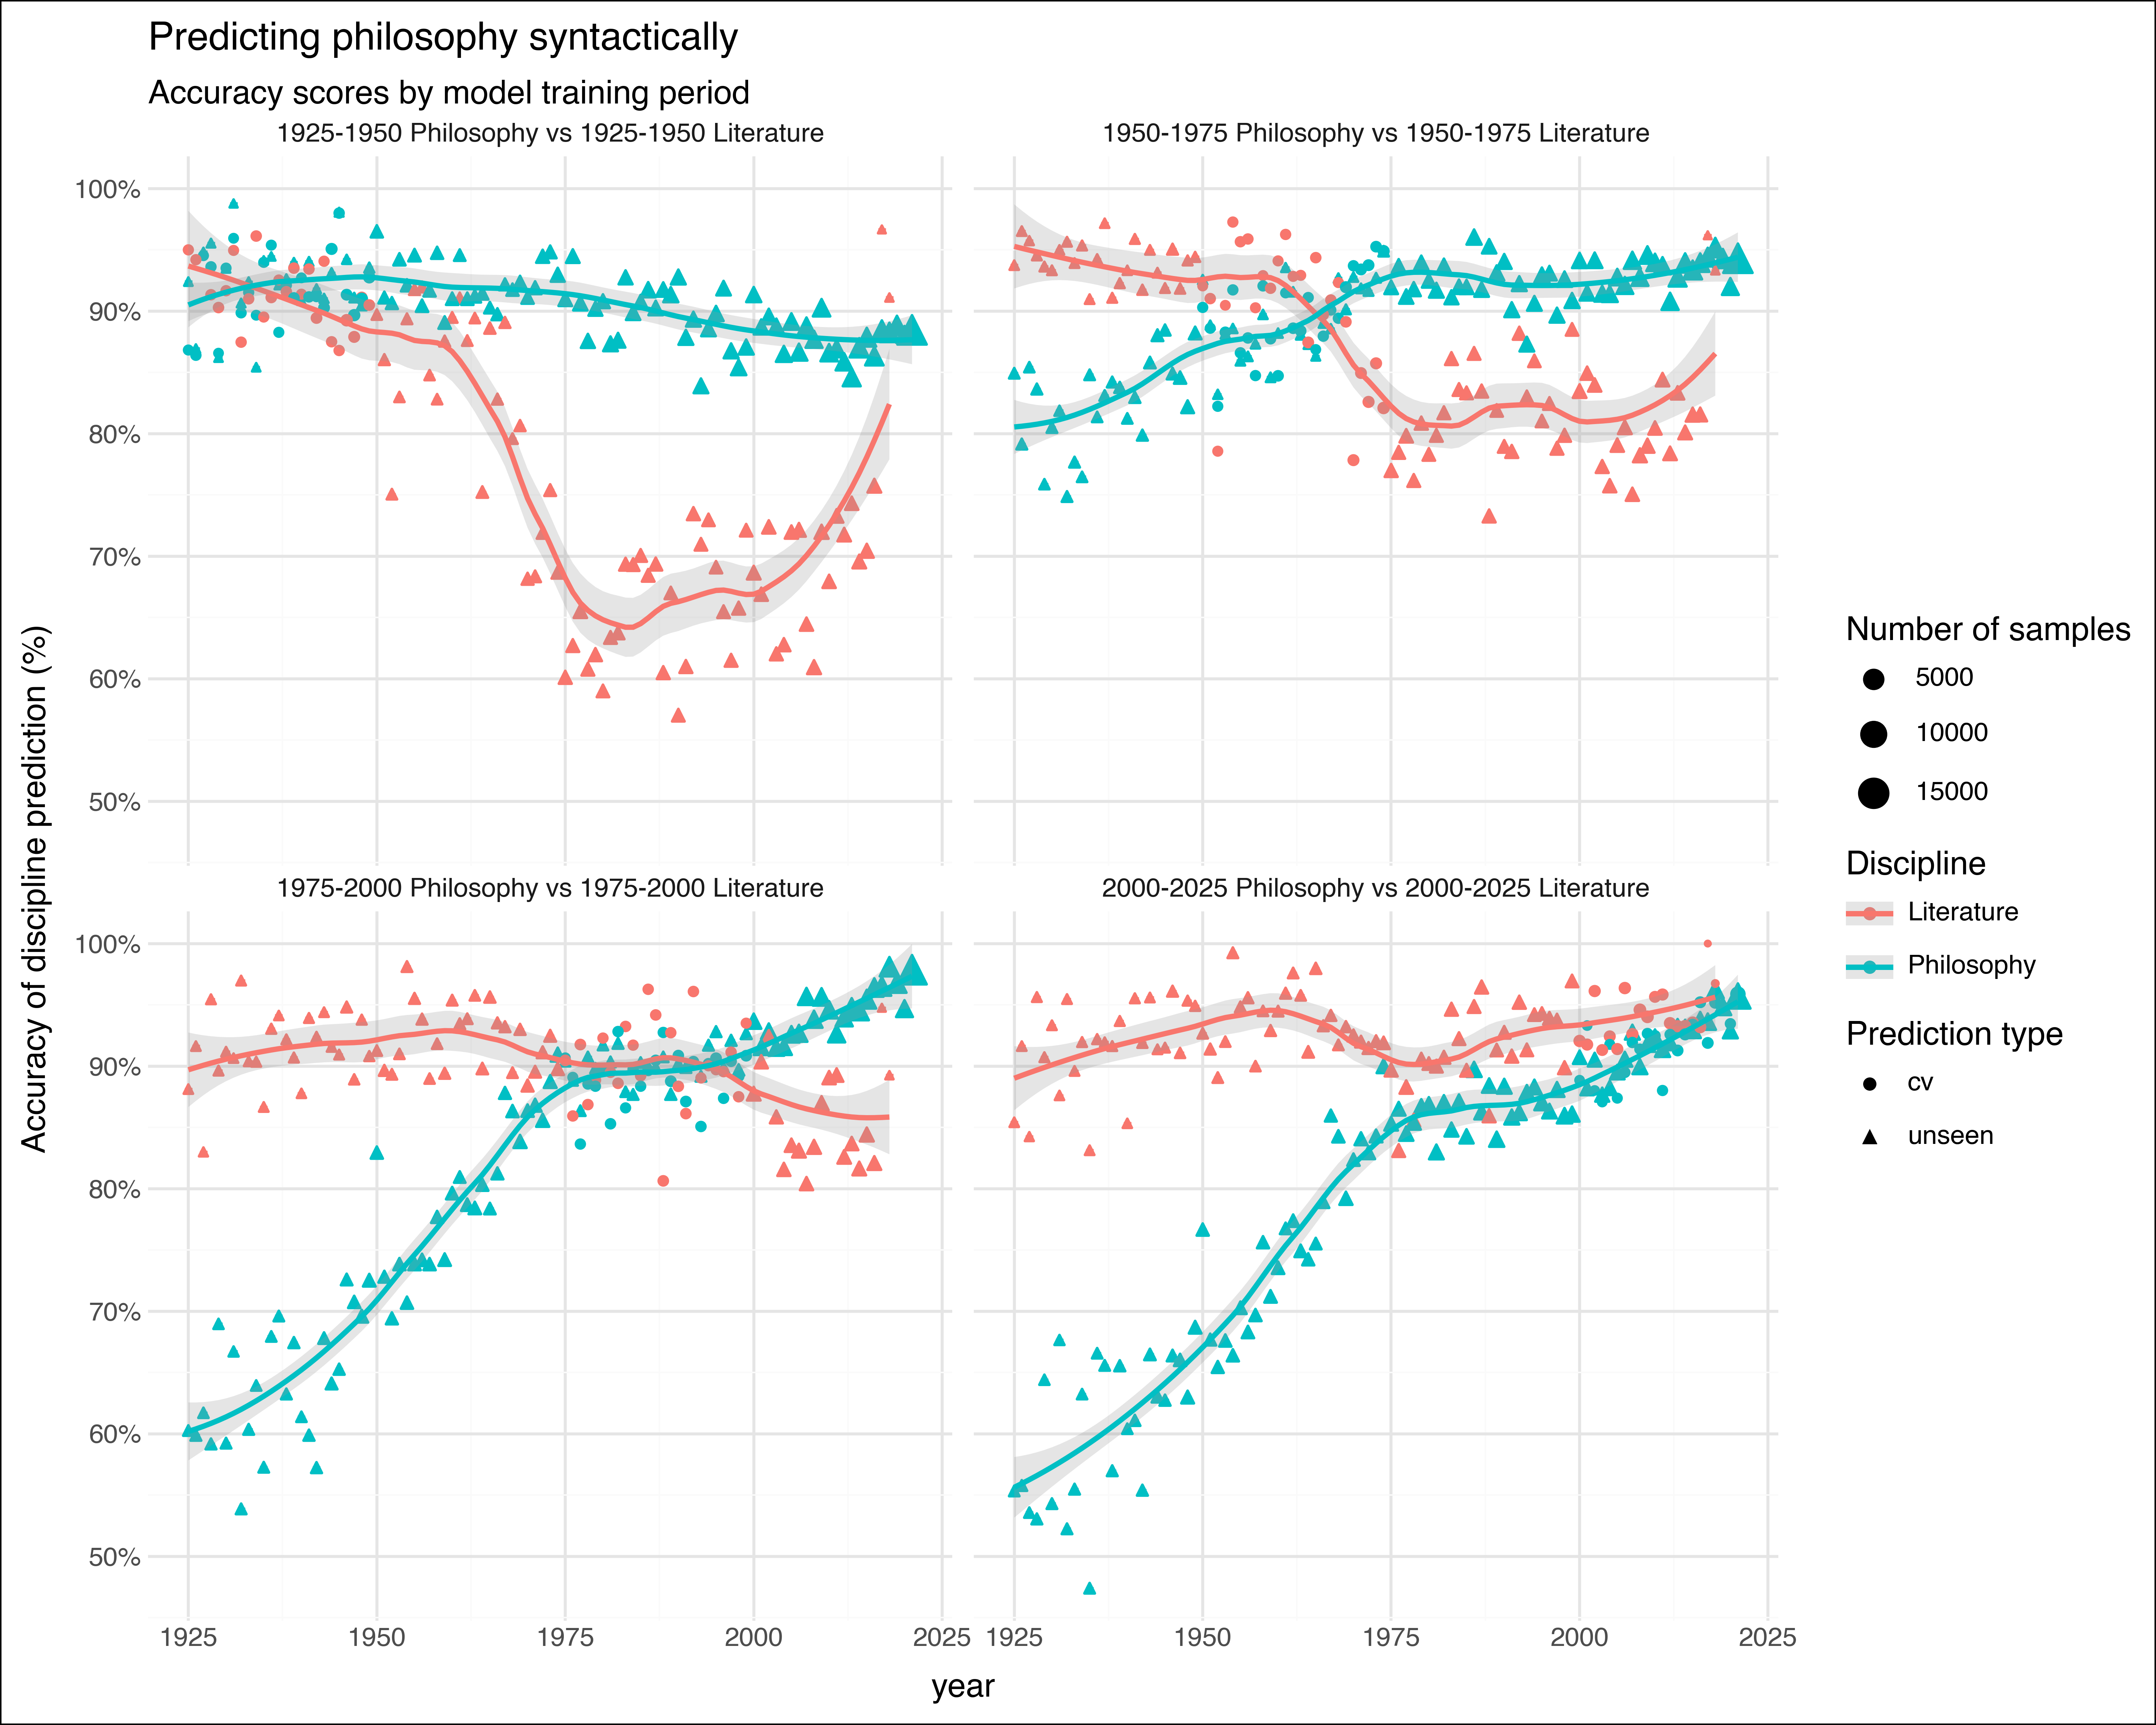

In [ ]:
def plot_preds(figdf, **labs):
    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x='year', y='mean', color='discipline'),
        )
        + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=1, alpha=0.75)
        + p9.geom_point(p9.aes(y='mean',size='count',shape='predict_type'))
        + p9.facet_wrap('comparison')
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        + p9.scale_y_continuous(labels=lambda l: [f'{int(v)}%' for v in l])
        + p9.geom_smooth(method='loess', span=0.5, alpha=0.25, size=1)
        + p9.labs(**labs)
        + p9.theme(
            plot_background=p9.element_rect(fill='white'),
            plot_title=p9.element_text(ha='left',size=13),
            plot_subtitle=p9.element_text(ha='left',size=11),
        )
    )
    return fig

figdf = get_avgs_df(odf,['comparison','discipline','year','decade','predict_type'],y='correct').reset_index()
figdf['mean']*=100

fig = plot_preds(
    figdf, 
    title="Predicting philosophy syntactically", 
    y="Accuracy of discipline prediction (%)",
    subtitle="Accuracy scores by model training period",
    size='Number of samples',
    shape='Prediction type',
    color='Discipline',
)
fig.save('../figures/preds_by_comparison.png')
fig

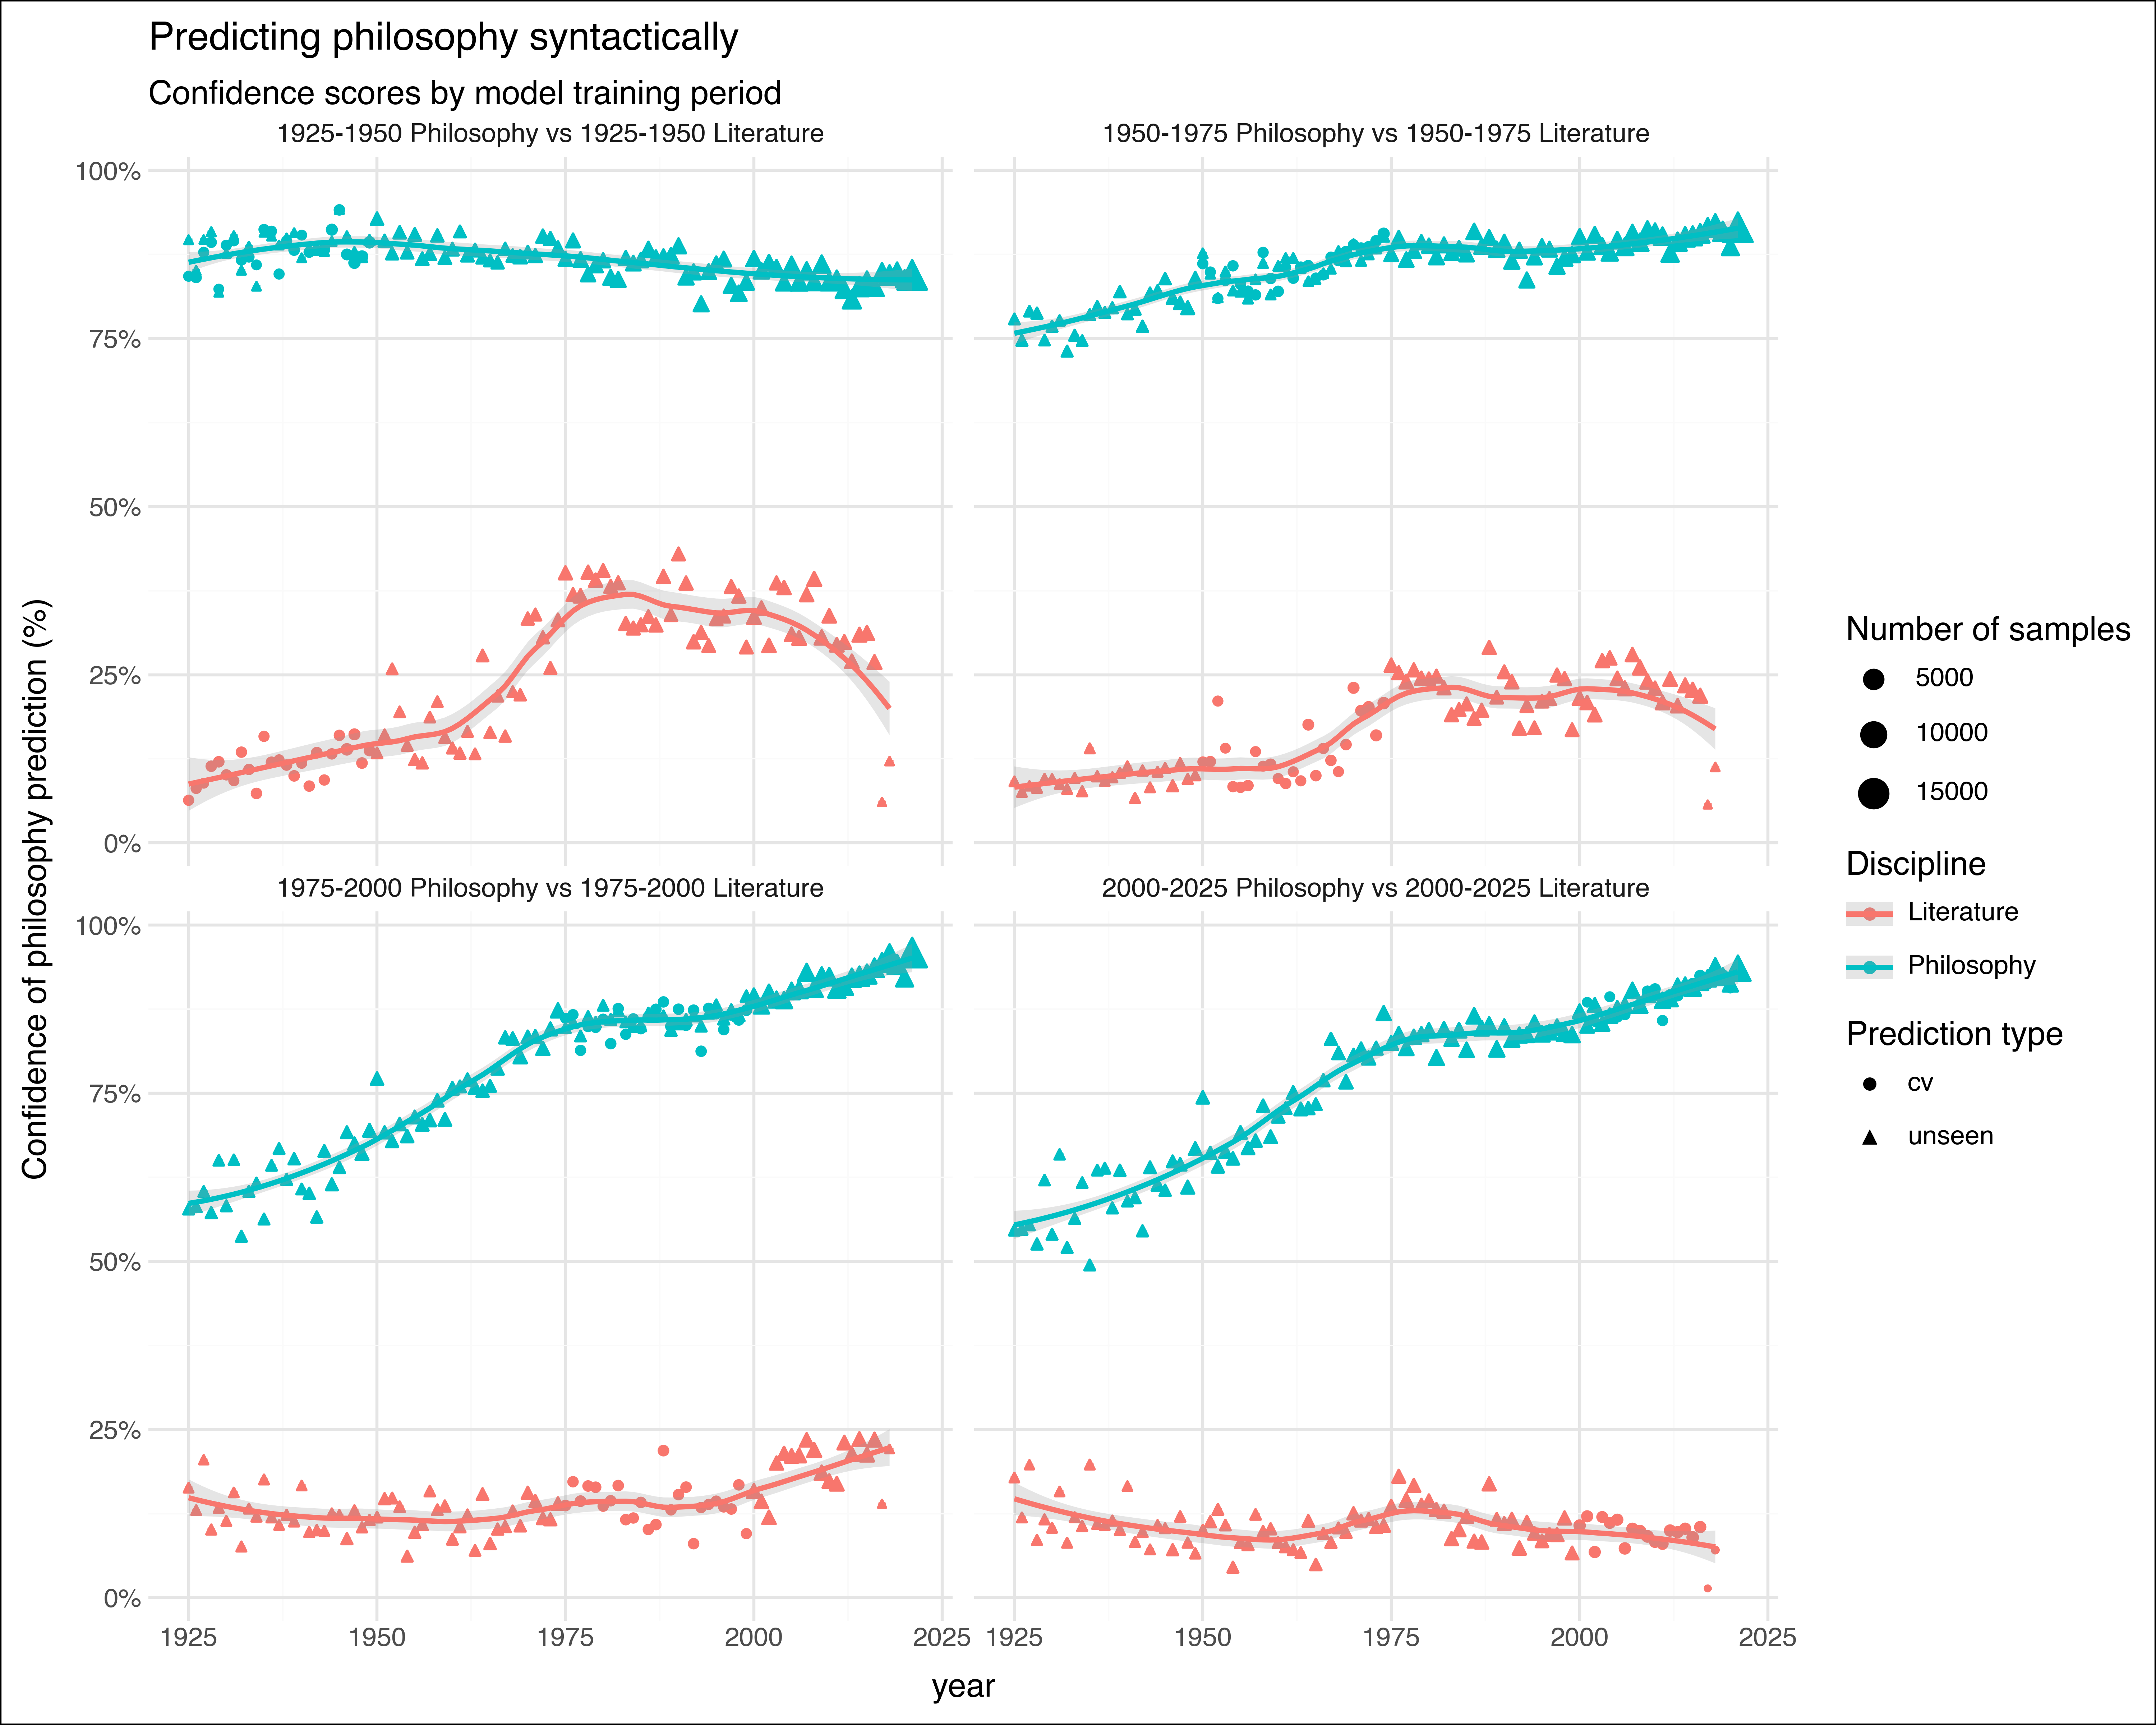

In [42]:
figdf = get_avgs_df(odf,['comparison','discipline','year','decade','predict_type'],y='prob2').reset_index()
figdf['mean']*=100

fig = plot_preds(
    figdf, 
    title="Predicting philosophy syntactically", 
    y="Confidence of philosophy prediction (%)",
    subtitle="Confidence scores by model training period",
    size='Number of samples',
    shape='Prediction type',
    color='Discipline',
)
fig.save('../figures/preds_by_comparison_prob.png')
fig# !pip install scikit-misc

In [12]:
stopp

NameError: name 'stopp' is not defined

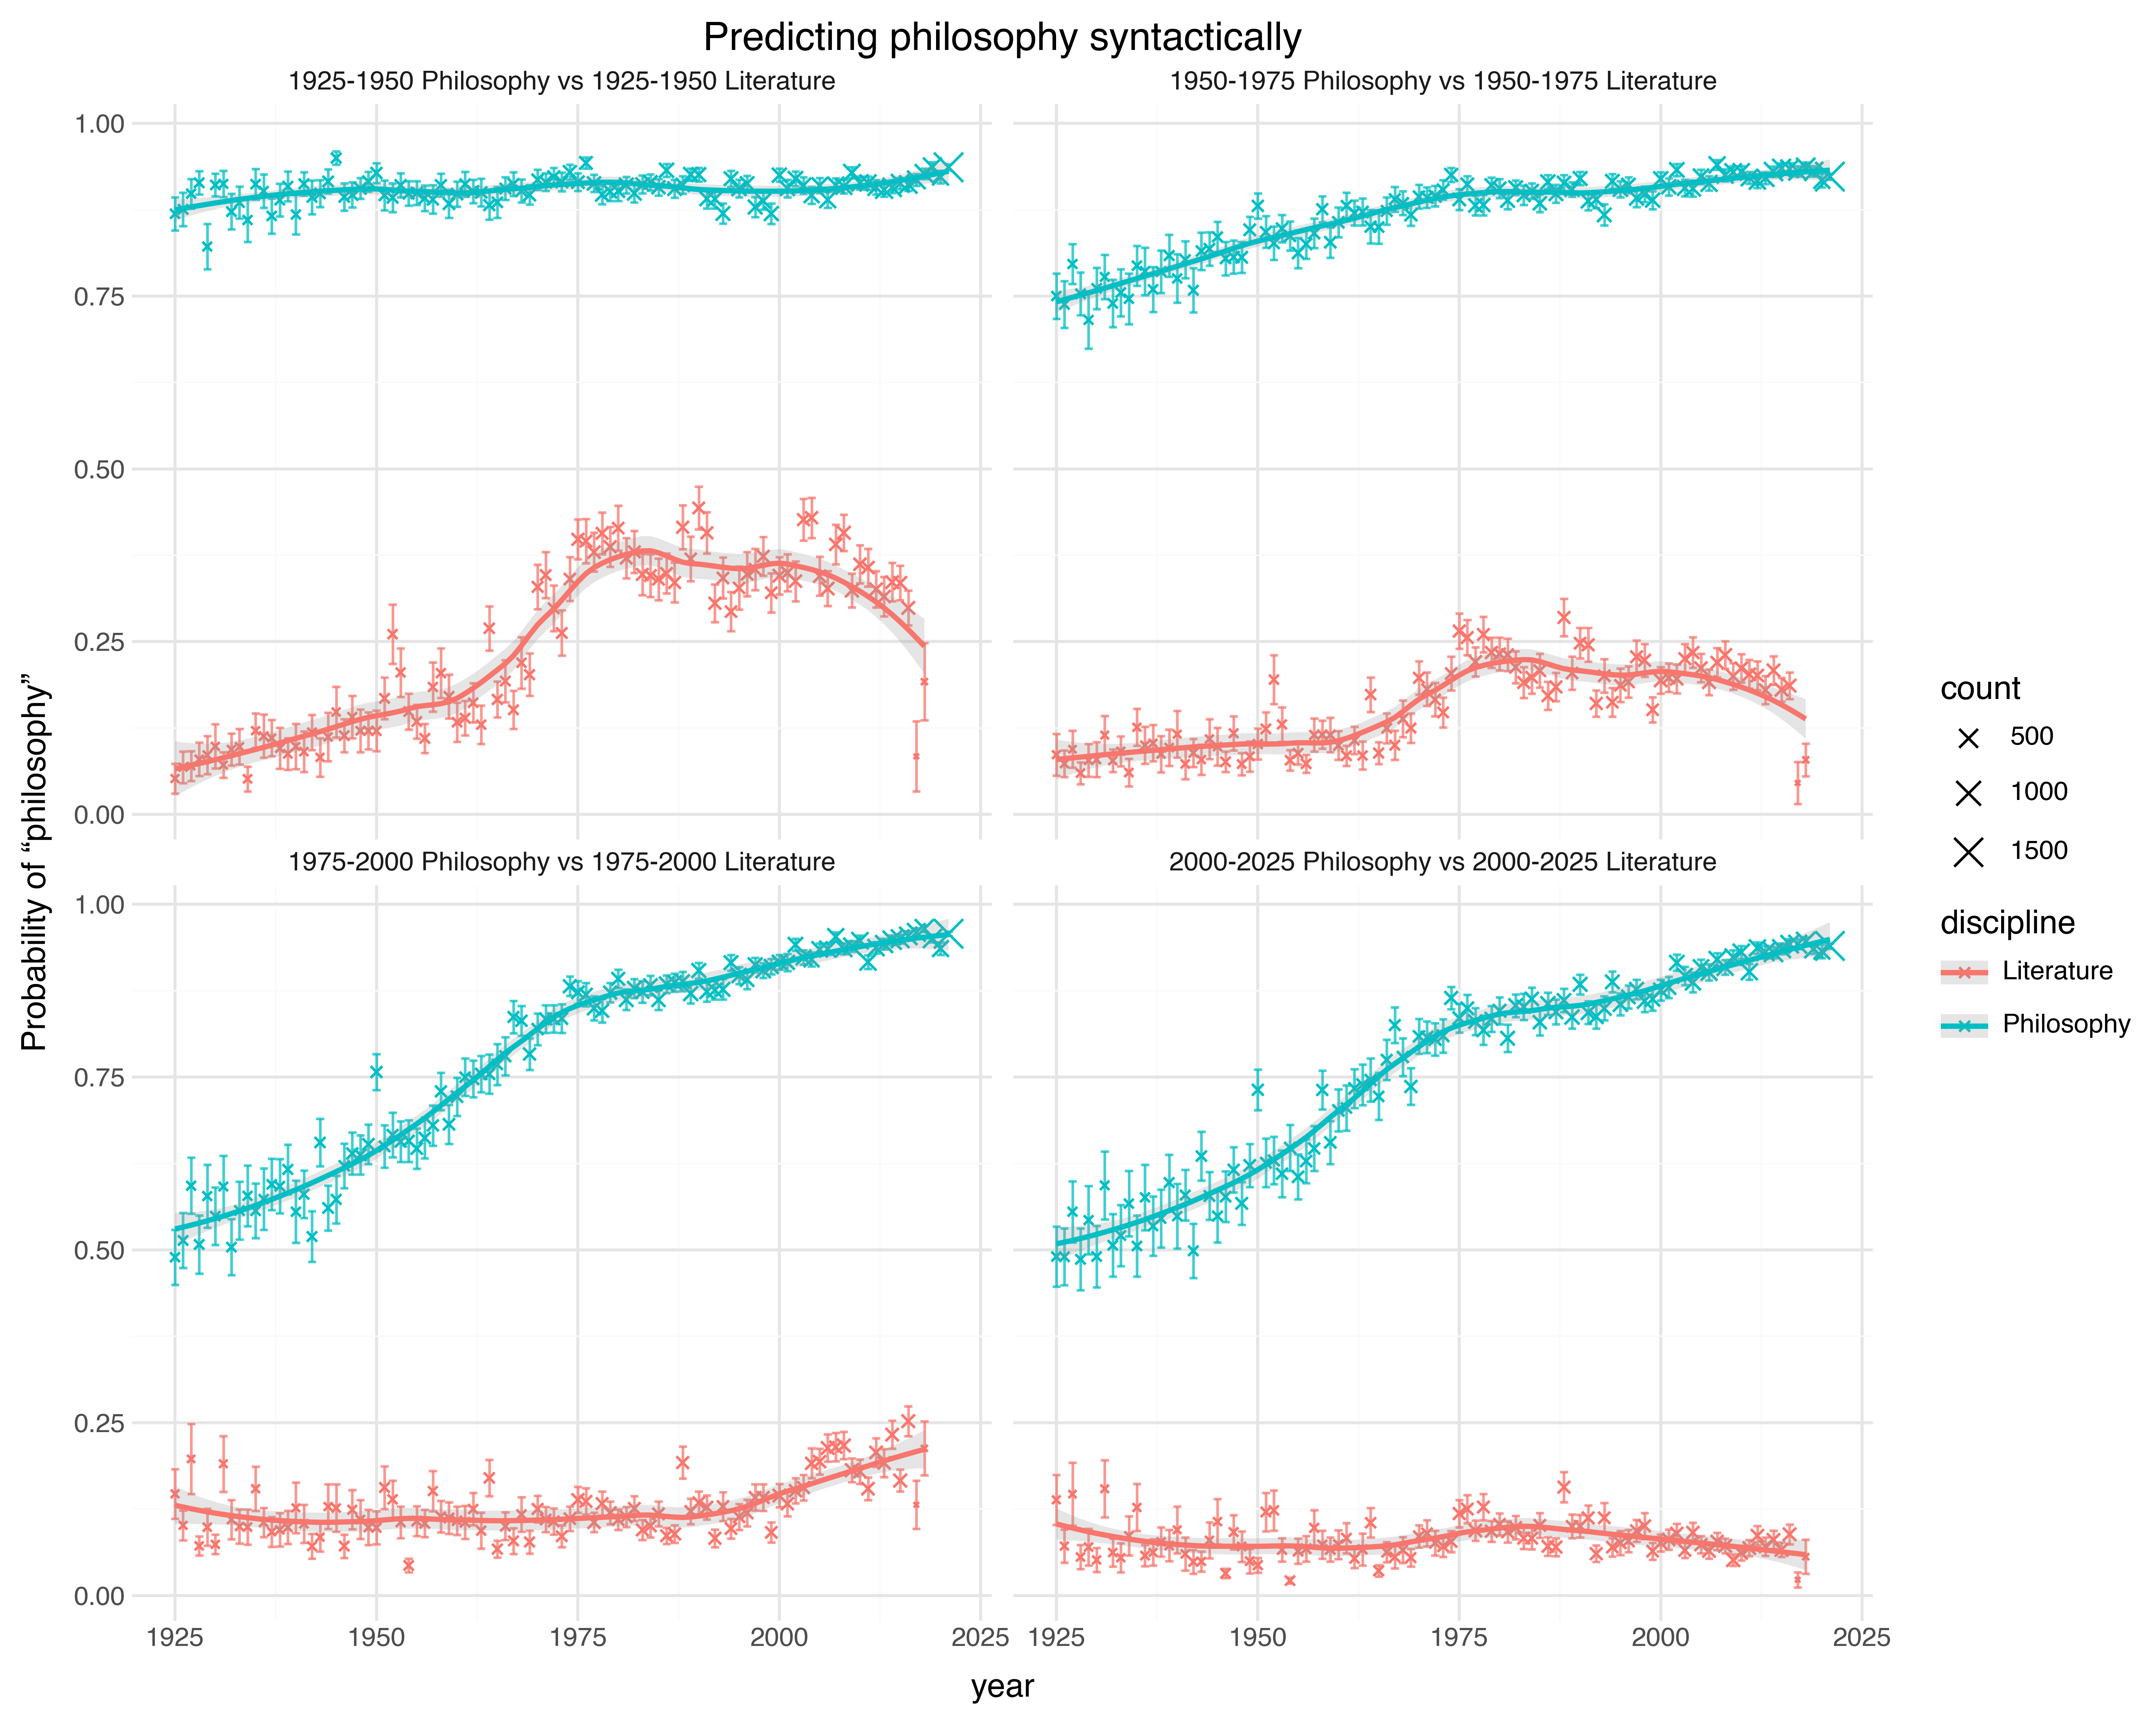

In [ ]:
figdf = get_avgs_df(odf,y='prob2').reset_index()
plot_avgs_df(figdf, title="Predicting philosophy syntactically", y="Probability of “philosophy”")

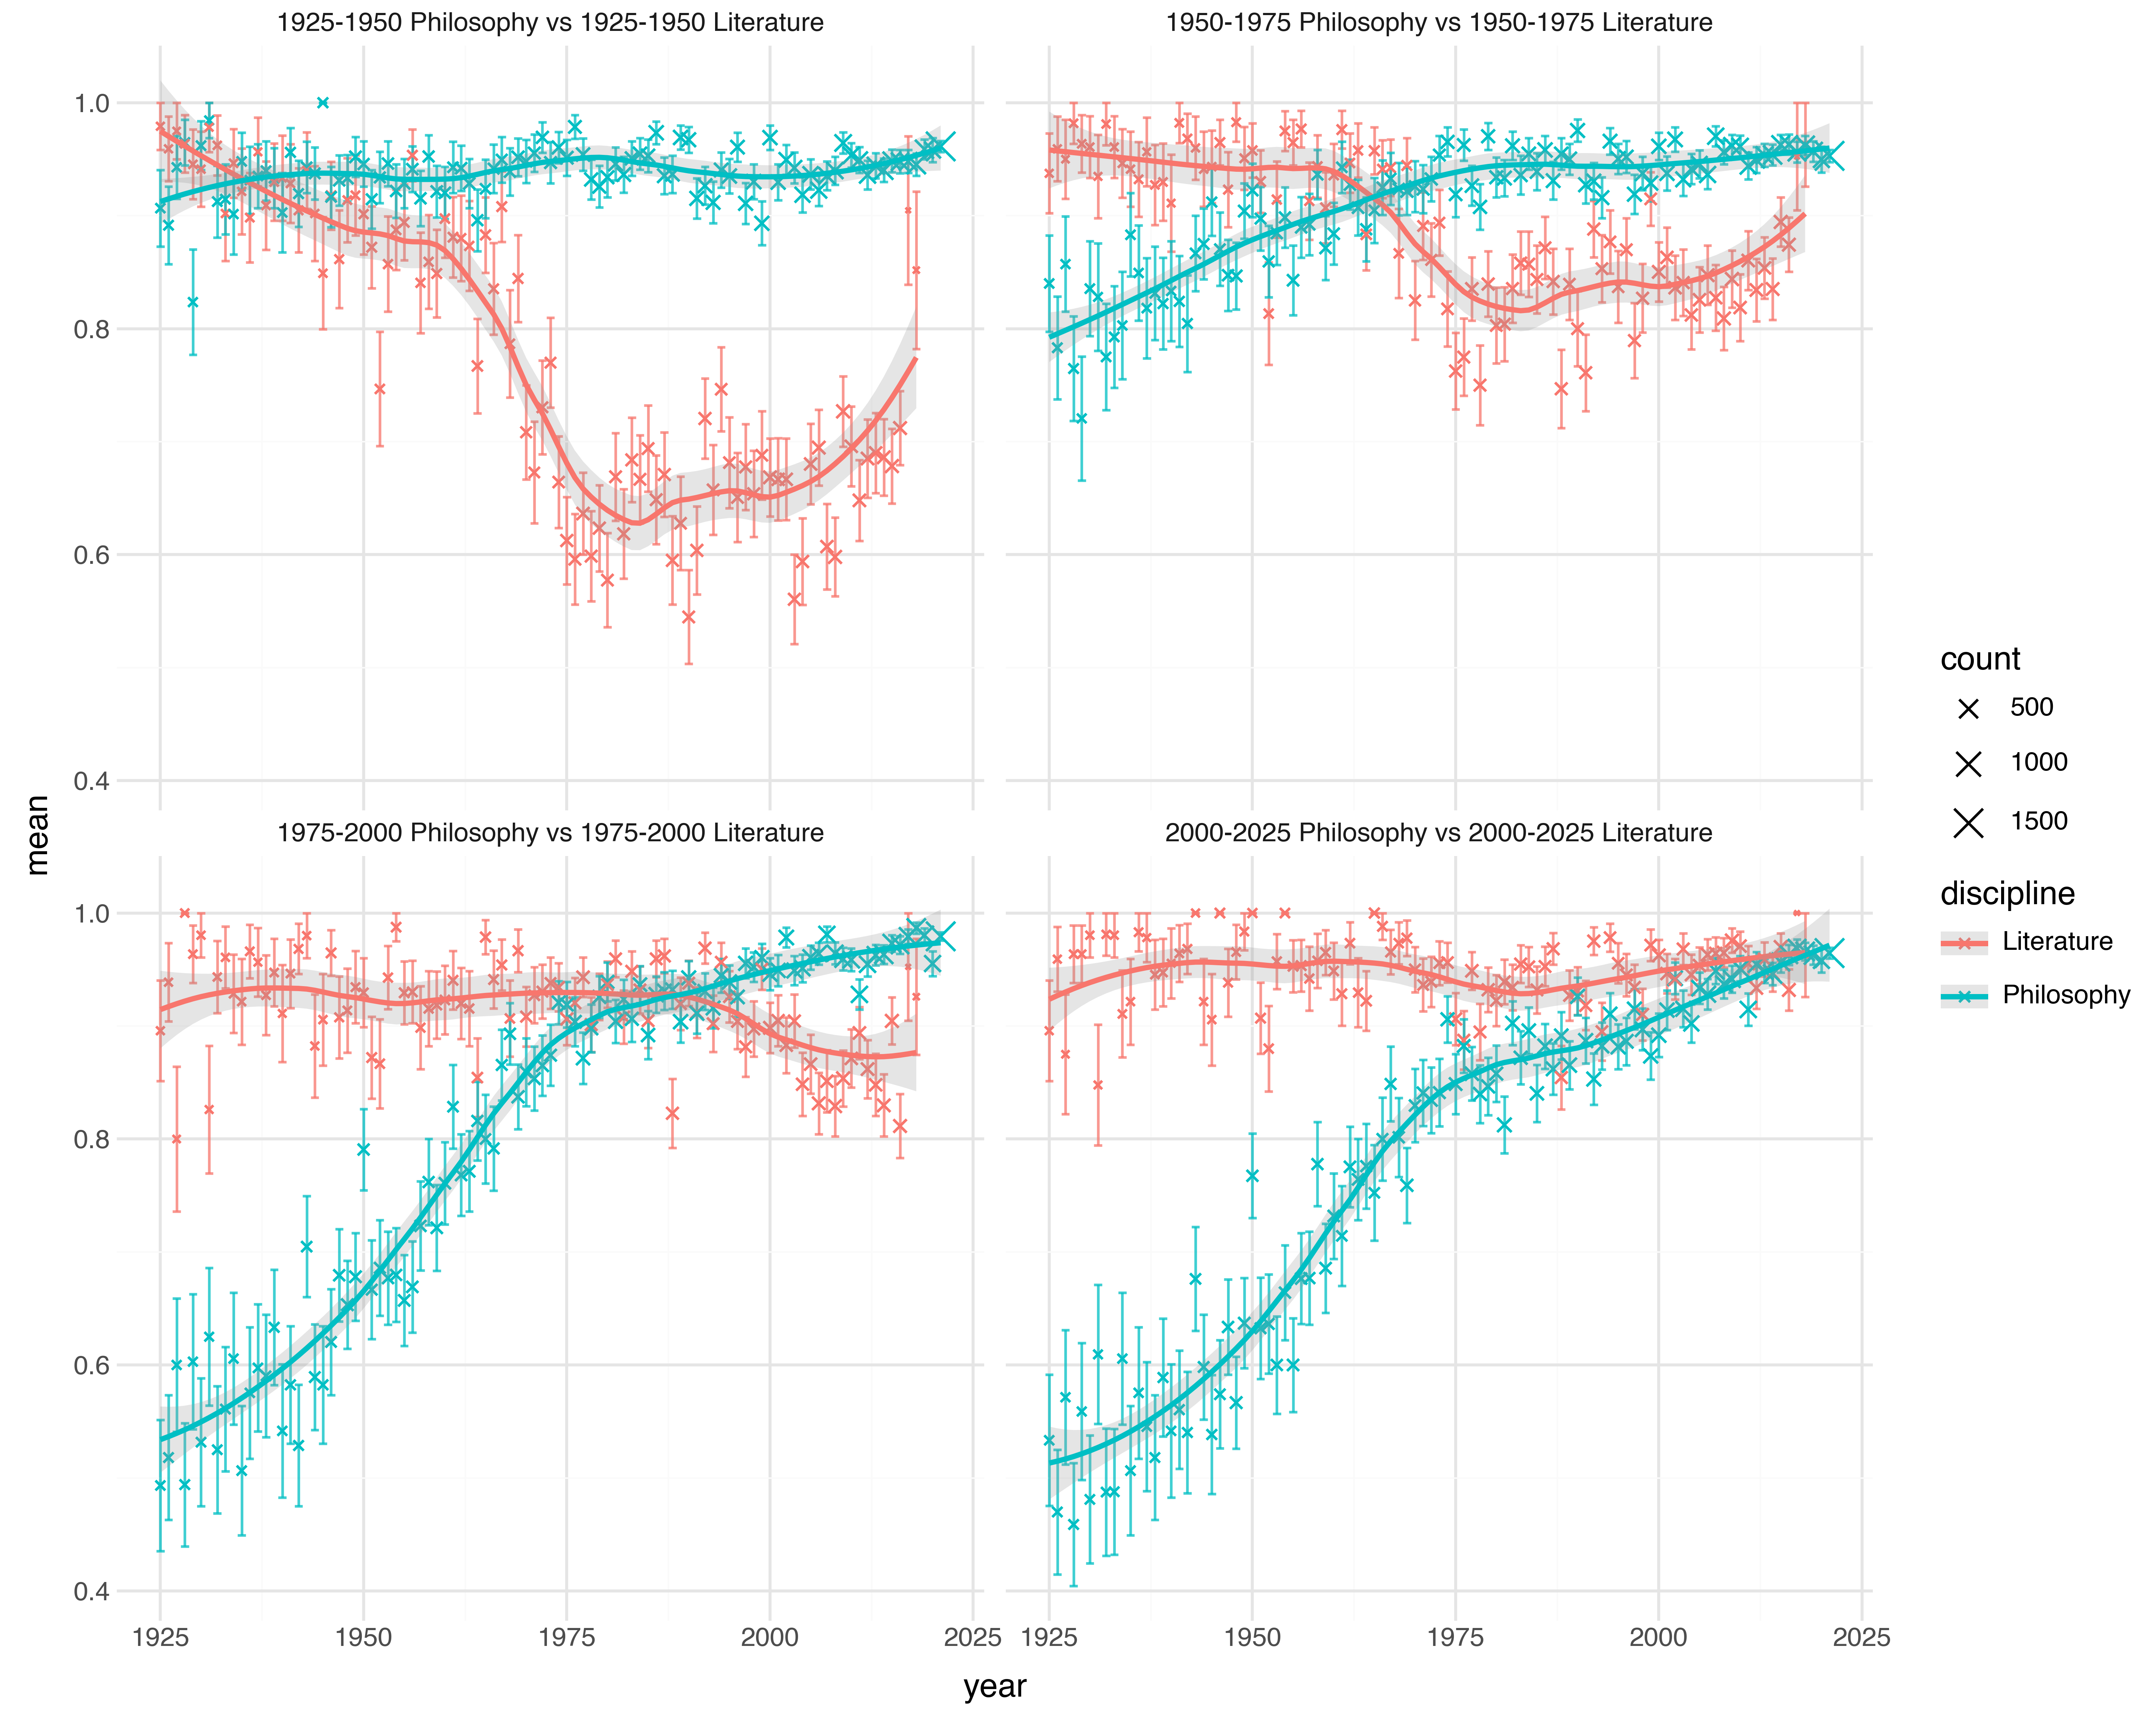

In [ ]:
figdf = get_avgs_df(odf,y='correct').reset_index()
plot_avgs_df(figdf)

In [ ]:
dfx=df_feats.groupby('feature').mean(numeric_only=True).sort_values('weight', ascending=False)

In [ ]:
dfx.tail(20)

,weight,run,fpk1,fpk2,odds_ratio,sum1,sum2,mdw_rank,mdw1_rank,mdw2_rank,feat1_rank,feat2_rank,feat_rank
feature,,,,,,,,,,,,,
deprel_obj,-0.150373,0.0,37.500,38.400,0.975,53499.00,26396.75,85.00,57.25,40.50,63.00,40.00,51.50
deprel_iobj,-0.158181,0.0,0.725,1.100,0.675,1003.25,736.00,30.00,81.25,16.50,73.25,29.75,60.25
pos_WRB,-0.178985,0.0,3.825,3.375,1.150,5582.25,2305.75,68.00,35.25,62.50,73.75,29.25,59.25
pos_RB,-0.180454,0.0,49.775,43.625,1.125,68665.75,29767.50,64.50,34.50,63.25,67.00,36.00,48.25
"pos_,",-0.184004,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.75,42.25,46.25
pos_VBN,-0.187070,0.0,23.225,24.325,0.975,30718.50,16304.25,87.25,58.00,39.75,73.25,29.75,58.75
ttr,-0.239154,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.75,31.25,12.50
deprel_root,-0.255013,0.0,37.150,36.650,1.025,51508.00,24552.50,78.75,52.50,45.25,69.00,34.00,24.75
deprel_dep,-0.255596,0.0,0.350,0.600,0.625,537.75,380.25,31.75,81.00,16.75,80.25,22.75,46.75


In [ ]:
dfx.head(30)

,weight,run,fpk1,fpk2,odds_ratio,sum1,sum2,mdw_rank,mdw1_rank,mdw2_rank,feat1_rank,feat2_rank,feat_rank
feature,,,,,,,,,,,,,
deprel_mark,0.651207,0.0,45.650,32.850,1.375,64506.00,22465.50,40.00,19.25,78.50,19.50,83.50,29.00
pos_SYM,0.610825,0.0,0.275,0.150,2.000,542.00,98.75,11.75,45.25,52.50,13.75,89.25,28.00
pos_MD,0.598494,0.0,16.600,10.050,1.700,22976.00,6728.00,24.00,11.75,86.00,11.25,91.75,18.75
sent_height,0.576012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.75,87.25,26.75
pos_DT,0.554924,0.0,103.200,103.100,1.000,139478.75,70369.75,92.25,52.50,45.25,10.25,92.75,18.25
deprel_advmod,0.506523,0.0,54.875,48.700,1.125,75923.25,33161.50,68.75,37.50,60.25,17.25,85.75,32.00
pos_VB,0.484311,0.0,37.775,27.500,1.375,53054.25,18674.50,39.75,19.25,78.50,13.25,89.75,28.75
deprel_nmod,0.465539,0.0,53.025,56.300,0.950,70886.00,38709.25,77.50,59.25,38.50,14.25,88.75,29.50
pos_NN,0.440901,0.0,148.800,144.250,1.050,204647.50,100388.25,84.00,47.25,50.50,25.75,77.25,49.50


In [ ]:
df_preds.groupby()

,prob1,prob2,pred_label,true_label,test_label,predict_type,run,comparison,text_id
id,,,,,,,,,
lit/20057585__05,0.521719,0.478281,Literature,Literature,Literature / Philosophy,unseen,0,C21 Philosophy vs C21 Literature,lit/20057585
lit/27654619__02,0.779358,0.220642,Literature,Literature,Literature / Philosophy,unseen,0,C21 Philosophy vs C21 Literature,lit/27654619
lit/40963178__02,0.387011,0.612989,Philosophy,Literature,Literature / Philosophy,unseen,0,C21 Philosophy vs C21 Literature,lit/40963178
lit/10.1086/658327__05,0.649940,0.350060,Literature,Literature,Literature / Philosophy,unseen,0,C21 Philosophy vs C21 Literature,lit/10.1086/658327
lit/30031962__02,0.634543,0.365457,Literature,Literature,Literature / Philosophy,unseen,0,C21 Philosophy vs C21 Literature,lit/30031962
...,...,...,...,...,...,...,...,...,...
phil/10.2307/4544337__03,0.614292,0.385708,Literature,Philosophy,Literature / Philosophy,unseen,9,lC20 Philosophy vs lC20 Literature,phil/10.2307/4544337
lit/459015__01,0.742329,0.257671,Literature,Literature,Literature / Philosophy,unseen,9,lC20 Philosophy vs lC20 Literature,lit/459015
lit/27760277__03,0.542627,0.457373,Literature,Literature,Literature / Philosophy,unseen,9,lC20 Philosophy vs lC20 Literature,lit/27760277
